In [1]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tabulate import tabulate

    - Function to format results into a table

In [2]:
# Custom function to display tables in a formatted way
def display_table(df: pd.DataFrame, title: str):
    """
    Display a formatted table for quick analysis and validation of results.

    Parameters
    ----------
    df (pd.DataFrame): DataFrame to be displayed.
    title (str): Title printed above the table.


    Returns
    -------
    df (pd.DataFrame)
    """

    print(f"\n{title}")
    if df is None:
        print("⚠️ No data provided.")
        return

    if isinstance(df, pd.Series):
        df = df.to_frame()

    if not isinstance(df, pd.DataFrame):
        print("⚠️ Invalid data format.")
        return

    if df.empty or df.shape[1] == 0:
        print("⚠️ No valid data or columns not found.")
        return

    colalign = ["center"] * len(df.columns)
    print(tabulate(df, headers="keys", tablefmt="fancy_grid", colalign=colalign, showindex=True, floatfmt=".8f"))

In [3]:
# Base directory where ETS results were saved
cache_dir = Path(r"D:\Hnsx\Formação Superior\0_Universidade Europeia\Mestrado em Ciência de Dados e Análise de Negócios\Curso\Tese_DataScience\Código\Tese_ETS_results")

# ETS test result folders
ets_paths = {"ETS Naive": cache_dir / "Tese_Bitcoin_Naive_test_rolling_step10_h120_pkl",
             "ETS Original": cache_dir / "Tese_Bitcoin_Variance_ret(L)_ETS_test_rolling_step10_h120_pkl",
             "ETS Logarithmic": cache_dir / "Tese_Bitcoin_Log-Variance_ret(L)_ETS_test_rolling_step10_h120_pkl",
             "ETS Yeo-Johnson": cache_dir / "Tese_Bitcoin_Yeo-Johnson-Variance_ret(L)_ETS_test_rolling_step10_h120_pkl"}

In [4]:
# Function to load ETS test results
def load_ets_test_result(model_name: str, folder_path: Path):
    """
    Load ETS test_results.parquet from a saved cache folder
    and add the model name.
    """

    test_file = folder_path / "test_results.parquet"

    if not test_file.exists():
        raise FileNotFoundError(f"File not found: {test_file}")

    df = pd.read_parquet(test_file).copy()
    df.insert(0, "Model", model_name)

    return df

In [5]:
# Load all ETS test results
ets_test_frames = []

for model_name, folder_path in ets_paths.items():
    df_tmp = load_ets_test_result(model_name, folder_path)
    ets_test_frames.append(df_tmp)

df_ets_all = pd.concat(ets_test_frames, ignore_index=True)

df_ets_compare_clean = df_ets_all.copy()

# Rename Naive row, if needed
df_ets_compare_clean["Model"] = (df_ets_compare_clean["Model"].astype(str).replace({"ETS Naive": "Naive"}))

# Drop unnecessary columns
cols_to_drop = ["model", "variant", "m"]
df_ets_compare_clean = df_ets_compare_clean.drop(columns=cols_to_drop, errors="ignore")

# Set Model as index
df_ets_compare_clean = df_ets_compare_clean.set_index("Model")

# Ensure these columns exist
for col in ["trend", "seasonal", "damped", "seasonal_periods"]:
    if col not in df_ets_compare_clean.columns:
        df_ets_compare_clean[col] = np.nan

# Convert damped to readable format
if "damped" in df_ets_compare_clean.columns:
    df_ets_compare_clean["damped"] = df_ets_compare_clean["damped"].replace({1.0: True, 0.0: False, "1.0": True, "0.0": False})

# Replace missing ETS configuration values with "-"
for col in ["trend", "seasonal", "damped", "seasonal_periods"]:
    df_ets_compare_clean[col] = (df_ets_compare_clean[col].astype(str).replace("nan", "-").replace("None", "-").replace("<NA>", "-"))

# Order columns: model configuration first, then metrics
config_cols = ["trend", "seasonal", "damped", "seasonal_periods"]

metric_cols = [c for c in df_ets_compare_clean.columns if c not in config_cols]

df_ets_compare_clean = df_ets_compare_clean[config_cols + metric_cols]

display_table(df_ets_compare_clean, "Loaded ETS test results - cleaned")


Loaded ETS test results - cleaned
╒═════════════════╤═════════╤════════════╤══════════╤════════════════════╤════════════╤════════════╤═════════════╤═════════════╤══════════════╤═════════════════╤══════════════════╤════════════════╤════════════════╤════════════════╤══════════════╤══════════════╤══════════════╤══════════════╤═══════════════╤══════════════╤══════════════╤══════════════╤══════════════╤═══════════════╤═══════════════════╤═══════════════════╤════════════════════╤════════════════════╤══════════════════╕
│      Model      │  trend  │  seasonal  │  damped  │  seasonal_periods  │  RMSE-h=1  │  RMSE-h=7  │  RMSE-h=15  │  RMSE-h=30  │  RMSE-h=120  │    MAPE-h=1     │     MAPE-h=7     │   MAPE-h=15    │   MAPE-h=30    │   MAPE-h=120   │  SMAPE-h=1   │  SMAPE-h=7   │  SMAPE-h=15  │  SMAPE-h=30  │  SMAPE-h=120  │  QLIKE-h=1   │  QLIKE-h=7   │  QLIKE-h=15  │  QLIKE-h=30  │  QLIKE-h=120  │  score_rmse_mean  │  score_mape_mean  │  score_smape_mean  │  score_qlike_mean  │   score_select

In [6]:
# Select RMSE columns
rmse_cols = sorted([c for c in df_ets_all.columns if c.startswith("RMSE-h=")], key=lambda x: int(x.split("=")[1]))

# Build clean comparison table
df_ets_rmse_compare = df_ets_all[["Model"] + rmse_cols + ["score_rmse_mean"]].copy()

# Rename columns for thesis-style display
rename_cols = {"RMSE-h=1": "h=1", "RMSE-h=7": "h=7", "RMSE-h=15": "h=15", "RMSE-h=30": "h=30", "RMSE-h=120": "h=120", "score_rmse_mean": "Mean RMSE"}

df_ets_rmse_compare = df_ets_rmse_compare.rename(columns=rename_cols)

# Set model as index
df_ets_rmse_compare = df_ets_rmse_compare.set_index("Model")

display_table(df_ets_rmse_compare, "Comparative test performance of ETS specifications across volatility-proxy representations")


Comparative test performance of ETS specifications across volatility-proxy representations
╒═════════════════╤════════════╤════════════╤════════════╤════════════╤════════════╤═════════════╕
│      Model      │    h=1     │    h=7     │    h=15    │    h=30    │   h=120    │   Mean RMSE │
╞═════════════════╪════════════╪════════════╪════════════╪════════════╪════════════╪═════════════╡
│    ETS Naive    │ 0.00102799 │ 0.00088119 │ 0.00075977 │ 0.00086042 │ 0.00090332 │  0.00088654 │
├─────────────────┼────────────┼────────────┼────────────┼────────────┼────────────┼─────────────┤
│  ETS Original   │ 0.00089405 │ 0.00066680 │ 0.00071446 │ 0.00066034 │ 0.00068445 │  0.00072402 │
├─────────────────┼────────────┼────────────┼────────────┼────────────┼────────────┼─────────────┤
│ ETS Logarithmic │ 0.00077239 │ 0.00043920 │ 0.00058566 │ 0.00058758 │ 0.00058999 │  0.00059497 │
├─────────────────┼────────────┼────────────┼────────────┼────────────┼────────────┼─────────────┤
│ ETS Yeo-Johnson

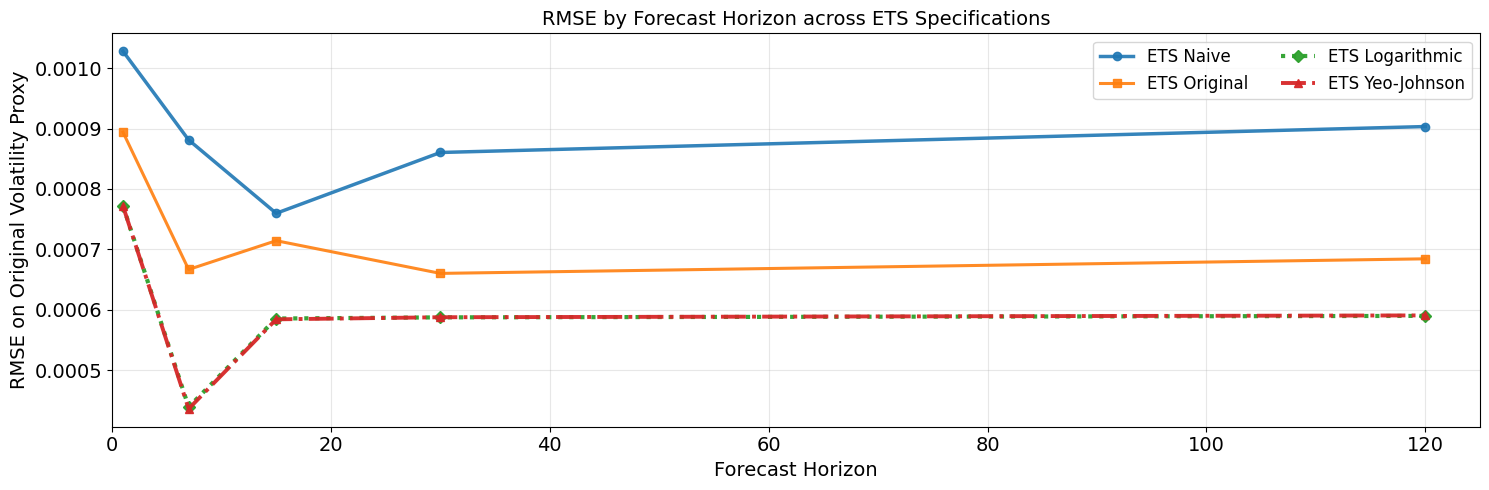

In [7]:
# Plot RMSE by forecast horizon for ETS specifications and Naive benchmark
def plot_ets_specifications_rmse(df_compare: pd.DataFrame):
    """
    Plot RMSE by forecast horizon for ETS Original, ETS Logarithmic,
    ETS Yeo-Johnson, and Naive benchmark.
    """

    horizon_cols = [c for c in df_compare.columns if c.startswith("h=")]
    horizons = [int(c.split("=")[1]) for c in horizon_cols]

    plt.figure(figsize=(15, 5))

    plot_styles = {"Naive": {"marker": "o", "linestyle": "--", "linewidth": 2.5, "alpha": 0.9, "zorder": 1},
                   "ETS Original": {"marker": "s", "linestyle": "-", "linewidth": 2.2, "alpha": 0.9, "zorder": 3},
                   "ETS Logarithmic": {"marker": "D", "linestyle": ":", "linewidth": 3.0, "alpha": 0.95, "zorder": 4},
                   "ETS Yeo-Johnson": {"marker": "^", "linestyle": "-.", "linewidth": 2.8, "alpha": 0.95, "zorder": 5}}

    for model_name in df_compare.index:
        rmse_values = df_compare.loc[model_name, horizon_cols].astype(float).values

        style = plot_styles.get(model_name, {"marker": "o", "linestyle": "-", "linewidth": 2.5, "alpha": 0.9, "zorder": 2})

        plt.plot(horizons, rmse_values, label=model_name, marker=style["marker"], linestyle=style["linestyle"], linewidth=style["linewidth"],
                 alpha=style["alpha"], zorder=style["zorder"])

    plt.title("RMSE by Forecast Horizon across ETS Specifications", fontsize=14)
    plt.xlabel("Forecast Horizon", fontsize=14)
    plt.ylabel("RMSE on Original Volatility Proxy", fontsize=14)

    # X-axis like the reference plot
    plt.xticks(np.arange(0, 121, 20), fontsize=14)
    plt.xlim(0, 125)

    plt.yticks(fontsize=14)

    # Legend with two columns
    plt.legend(fontsize=12, loc="upper right", ncol=2, frameon=True)

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_ets_specifications_rmse(df_ets_rmse_compare)